In [1]:
import pandas as pd
import numpy as np
import os
import time
import json
import pickle
import warnings
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    precision_score,
    recall_score
)

warnings.filterwarnings('ignore')

# Optional directories
os.makedirs('../models/binary', exist_ok=True)
os.makedirs('../results/binary', exist_ok=True)

# Load NEW binary split data
print("Loading binary split data...")
X_train = pd.read_csv('../extracted/X_train_binary.csv')
X_val   = pd.read_csv('../extracted/X_val_binary.csv')
X_test  = pd.read_csv('../extracted/X_test_binary.csv')

y_train = pd.read_csv('../extracted/y_train_binary.csv').squeeze()
y_val   = pd.read_csv('../extracted/y_val_binary.csv').squeeze()
y_test  = pd.read_csv('../extracted/y_test_binary.csv').squeeze()

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")
print(f"Train distribution: {y_train.value_counts().to_dict()}")
print(f"Val distribution:   {y_val.value_counts().to_dict()}")
print(f"Test distribution:  {y_test.value_counts().to_dict()}")

Loading binary split data...
Train: (14703605, 39)
Val:   (2100516, 39)
Test:  (4201031, 39)
Train distribution: {1: 13970490, 0: 733115}
Val distribution:   {1: 1995785, 0: 104731}
Test distribution:  {1: 3991569, 0: 209462}


In [2]:
def compute_binary_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted'),
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
        'precision_benign': precision_score(y_true, y_pred, pos_label=0),
        'recall_benign': recall_score(y_true, y_pred, pos_label=0),
        'precision_attack': precision_score(y_true, y_pred, pos_label=1),
        'recall_attack': recall_score(y_true, y_pred, pos_label=1),
        'roc_auc': roc_auc_score(y_true, y_prob),
        'pr_auc': average_precision_score(y_true, y_prob),
        'mcc': matthews_corrcoef(y_true, y_pred),
        'fpr': fp / (fp + tn) if (fp + tn) > 0 else 0.0,
        'fnr': fn / (fn + tp) if (fn + tp) > 0 else 0.0,
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
        'tp': int(tp)
    }
    return metrics

Training Random Forest...
Training time: 153.9s

=== RANDOM FOREST — VALIDATION ===
Accuracy: 0.9854
F1 Macro: 0.9232
ROC-AUC:  0.9959
PR-AUC:   0.9998

=== RANDOM FOREST — TEST ===
accuracy: 0.9855
f1_weighted: 0.9855
f1_macro: 0.9238
precision_benign: 0.8543
recall_benign: 0.8560
precision_attack: 0.9924
recall_attack: 0.9923
roc_auc: 0.9960
pr_auc: 0.9998
mcc: 0.8475
fpr: 0.1440
fnr: 0.0077
tn: 179291
fp: 30171
fn: 30580
tp: 3960989

Classification Report (Test):
              precision    recall  f1-score   support

      Benign     0.8543    0.8560    0.8551    209462
      Attack     0.9924    0.9923    0.9924   3991569

    accuracy                         0.9855   4201031
   macro avg     0.9234    0.9241    0.9238   4201031
weighted avg     0.9856    0.9855    0.9855   4201031



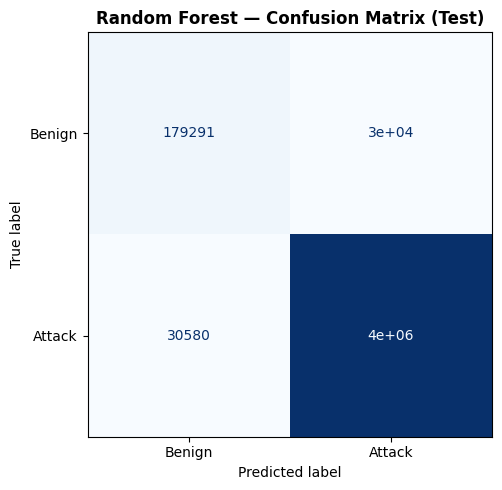

Saved: ../results/binary/rf_confusion_matrix.png


In [3]:
# === MODEL 1: Random Forest ===
print("Training Random Forest...")
t0 = time.time()

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf.fit(X_train, y_train)
rf_time = time.time() - t0
print(f"Training time: {rf_time:.1f}s")

# Validation
rf_val_pred = rf.predict(X_val)
rf_val_prob = rf.predict_proba(X_val)[:, 1]

print(f"\n=== RANDOM FOREST — VALIDATION ===")
print(f"Accuracy: {accuracy_score(y_val, rf_val_pred):.4f}")
print(f"F1 Macro: {f1_score(y_val, rf_val_pred, average='macro'):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_val, rf_val_prob):.4f}")
print(f"PR-AUC:   {average_precision_score(y_val, rf_val_prob):.4f}")

# Test
rf_test_pred = rf.predict(X_test)
rf_test_prob = rf.predict_proba(X_test)[:, 1]
rf_metrics = compute_binary_metrics(y_test, rf_test_pred, rf_test_prob)

print(f"\n=== RANDOM FOREST — TEST ===")
for k, v in rf_metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

print("\nClassification Report (Test):")
print(classification_report(
    y_test, rf_test_pred,
    target_names=['Benign', 'Attack'],
    digits=4
))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, rf_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Attack'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Random Forest — Confusion Matrix (Test)', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/binary/rf_confusion_matrix.png', dpi=150)
plt.show()

print("Saved: ../results/binary/rf_confusion_matrix.png")

Training XGBoost...
Training time: 46.2s

=== XGBOOST — VALIDATION ===
Accuracy: 0.9719
F1 Macro: 0.8822
ROC-AUC:  0.9960
PR-AUC:   0.9998

=== XGBOOST — TEST ===
accuracy: 0.9720
f1_weighted: 0.9749
f1_macro: 0.8828
precision_benign: 0.6409
recall_benign: 0.9982
precision_attack: 0.9999
recall_attack: 0.9707
roc_auc: 0.9961
pr_auc: 0.9998
mcc: 0.7880
fpr: 0.0018
fnr: 0.0293
tn: 209088
fp: 374
fn: 117145
tp: 3874424

Classification Report (Test):
              precision    recall  f1-score   support

      Benign     0.6409    0.9982    0.7806    209462
      Attack     0.9999    0.9707    0.9851   3991569

    accuracy                         0.9720   4201031
   macro avg     0.8204    0.9844    0.8828   4201031
weighted avg     0.9820    0.9720    0.9749   4201031



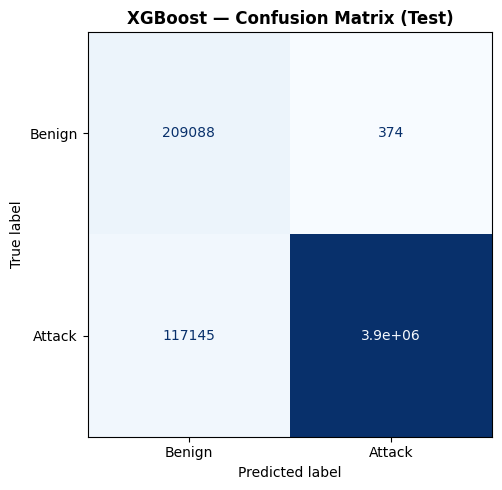

Saved: ../results/binary/xgb_confusion_matrix.png


In [4]:
# === MODEL 2: XGBoost ===
print("Training XGBoost...")
t0 = time.time()

scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_time = time.time() - t0
print(f"Training time: {xgb_time:.1f}s")

# Validation
xgb_val_pred = xgb_model.predict(X_val)
xgb_val_prob = xgb_model.predict_proba(X_val)[:, 1]

print(f"\n=== XGBOOST — VALIDATION ===")
print(f"Accuracy: {accuracy_score(y_val, xgb_val_pred):.4f}")
print(f"F1 Macro: {f1_score(y_val, xgb_val_pred, average='macro'):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_val, xgb_val_prob):.4f}")
print(f"PR-AUC:   {average_precision_score(y_val, xgb_val_prob):.4f}")

# Test
xgb_test_pred = xgb_model.predict(X_test)
xgb_test_prob = xgb_model.predict_proba(X_test)[:, 1]
xgb_metrics = compute_binary_metrics(y_test, xgb_test_pred, xgb_test_prob)

print(f"\n=== XGBOOST — TEST ===")
for k, v in xgb_metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

print("\nClassification Report (Test):")
print(classification_report(
    y_test, xgb_test_pred,
    target_names=['Benign', 'Attack'],
    digits=4
))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, xgb_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Attack'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('XGBoost — Confusion Matrix (Test)', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/binary/xgb_confusion_matrix.png', dpi=150)
plt.show()

print("Saved: ../results/binary/xgb_confusion_matrix.png")

In [5]:
# === FINAL ML COMPARISON ===
results = [
    {
        'Model': 'Random Forest',
        'Accuracy': rf_metrics['accuracy'],
        'F1 Weighted': rf_metrics['f1_weighted'],
        'F1 Macro': rf_metrics['f1_macro'],
        'ROC-AUC': rf_metrics['roc_auc'],
        'PR-AUC': rf_metrics['pr_auc'],
        'MCC': rf_metrics['mcc'],
        'Benign Precision': rf_metrics['precision_benign'],
        'Benign Recall': rf_metrics['recall_benign'],
        'Attack Precision': rf_metrics['precision_attack'],
        'Attack Recall': rf_metrics['recall_attack'],
        'FPR': rf_metrics['fpr'],
        'FNR': rf_metrics['fnr'],
        'Train Time (s)': rf_time
    },
    {
        'Model': 'XGBoost',
        'Accuracy': xgb_metrics['accuracy'],
        'F1 Weighted': xgb_metrics['f1_weighted'],
        'F1 Macro': xgb_metrics['f1_macro'],
        'ROC-AUC': xgb_metrics['roc_auc'],
        'PR-AUC': xgb_metrics['pr_auc'],
        'MCC': xgb_metrics['mcc'],
        'Benign Precision': xgb_metrics['precision_benign'],
        'Benign Recall': xgb_metrics['recall_benign'],
        'Attack Precision': xgb_metrics['precision_attack'],
        'Attack Recall': xgb_metrics['recall_attack'],
        'FPR': xgb_metrics['fpr'],
        'FNR': xgb_metrics['fnr'],
        'Train Time (s)': xgb_time
    }
]

results_df = pd.DataFrame(results)
results_df.to_csv('../results/binary/ml_baseline_results_binary.csv', index=False)
print("=== ML BASELINE RESULTS ===")
print(results_df.to_string(index=False))
print("\nSaved: ../results/binary/ml_baseline_results_binary.csv")

=== ML BASELINE RESULTS ===
        Model  Accuracy  F1 Weighted  F1 Macro  ROC-AUC   PR-AUC      MCC  Benign Precision  Benign Recall  Attack Precision  Attack Recall      FPR      FNR  Train Time (s)
Random Forest  0.985539     0.985546  0.923757 0.996003 0.999767 0.847515          0.854291       0.855960          0.992441       0.992339 0.144040 0.007661      153.943144
      XGBoost  0.972026     0.974867  0.882842 0.996137 0.999800 0.787952          0.640916       0.998214          0.999903       0.970652 0.001786 0.029348       46.231579

Saved: ../results/binary/ml_baseline_results_binary.csv


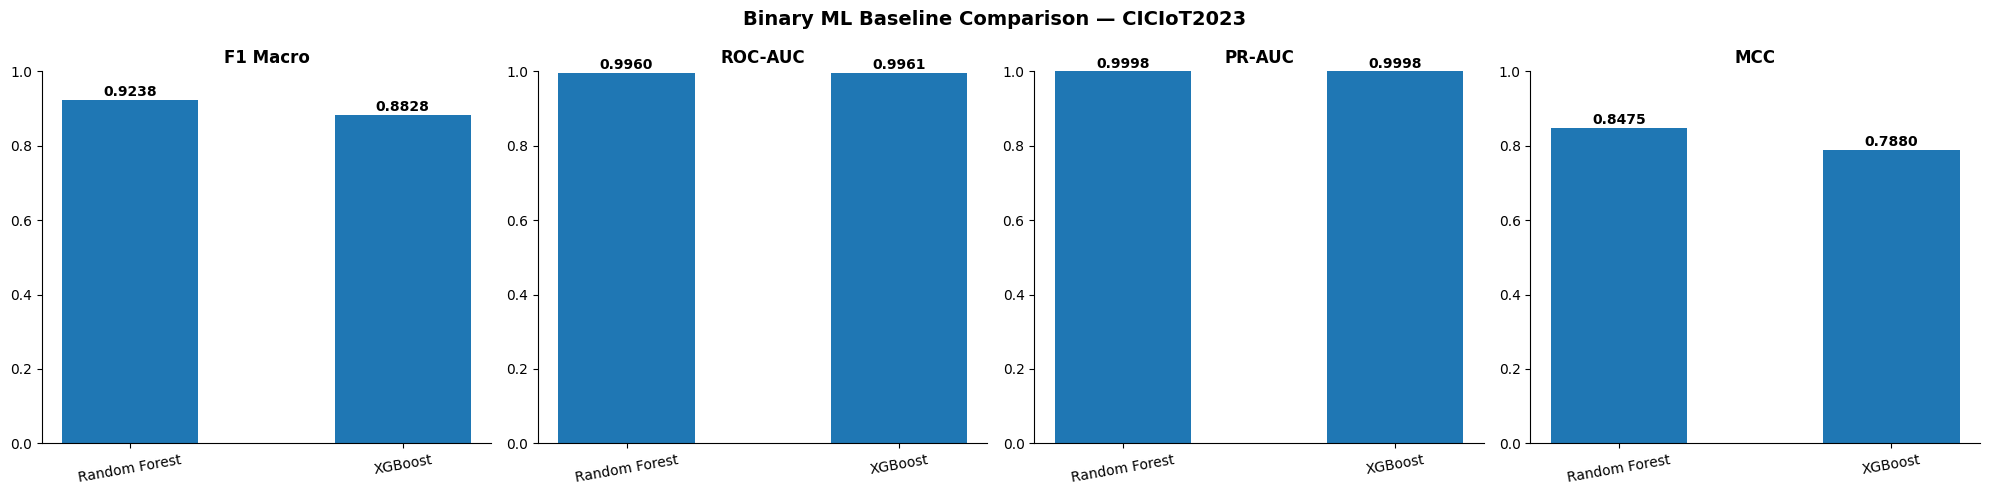

Saved: ../results/binary/ml_baseline_comparison_binary.png


In [6]:
# === COMPARISON PLOTS ===
plot_metrics = ['F1 Macro', 'ROC-AUC', 'PR-AUC', 'MCC']
models = results_df['Model'].tolist()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, metric in zip(axes, plot_metrics):
    vals = results_df[metric].tolist()
    bars = ax.bar(models, vals, width=0.5)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.0 if metric != 'Train Time (s)' else max(vals)*1.1)
    ax.tick_params(axis='x', rotation=10)

    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{val:.4f}',
            ha='center',
            fontsize=10,
            fontweight='bold'
        )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(
    'Binary ML Baseline Comparison — CICIoT2023',
    fontsize=14,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('../results/binary/ml_baseline_comparison_binary.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: ../results/binary/ml_baseline_comparison_binary.png")

In [ ]:
# Save trained models
pickle.dump(rf, open('../models/binary/rf_model.pkl', 'wb'))
pickle.dump(xgb_model, open('../models/binary/xgb_model.pkl', 'wb'))

print("Saved: ../models/binary/rf_model.pkl")
print("Saved: ../models/binary/xgb_model.pkl")

Saved: ../models/binary/rf_model.pkl
Saved: ../models/binary/xgb_model.pkl


: 